In [2]:
import pandas as pd
import os

# === CONFIGURATION ===
dir_path = 'TSP-BDa_Outer_300_1500_10-Toden-AD'
files = [
    'CIBERSORTx_Results.txt',
    'NNLS_All-AD_Counts_v46_Clean_UniquePatients_CPM.txt',
    'nuSVR_Counts_TSP-BDa_Outer_300_1500_10-Toden-AD.txt',
    'QP_All-AD_Counts_v46_Clean_UniquePatients_CPM_composition.txt',
    'TSP-BDa_Inner_100each_seed42_filtered_All-AD_Counts_v46_Clean_UniquePatients_CPM_BayesPrism_renamed.txt',
    'TSP-HBA_Inner_100each_seed42-ReDeconv_Top1500_ReDeconv_results.tsv',
    'TSP-HBA_Inner_100each_seed42_Toden_AD_MuSiC.txt'
]

method_map = ['CIBERSORTx', 'MuSiC', 'QP', 'NNLS', 'BayesPrism', 'nuSVR', 'ReDeconv']

def normalize_to_100(df):
    numeric_cols = df.select_dtypes(include='number').columns
    df[numeric_cols] = df[numeric_cols].div(df[numeric_cols].sum(axis=1), axis=0) * 100
    return df

def clean_dataframe(df, file):
    if (
        file.endswith('BayesPrism_renamed.txt') or
        file.endswith('MuSiC.txt') or
        file.startswith('CIBERSORTx_Results') or
        file.endswith('ReDeconv_results.tsv')
    ):
        if file.startswith('CIBERSORTx_Results'):
            df = df.drop(columns=['P-value', 'Correlation', 'RMSE'], errors='ignore')
        df = normalize_to_100(df)

    elif file.startswith('QP') or file.startswith('NNLS'):
        df = df.drop(columns=[
            'RMSE-Composition', 'r-Composition',
            'RMSE-PredictedCounts', 'r-PredictedCounts'
        ], errors='ignore')

    return df.round(5)

def detect_method(filename):
    return next((m for m in method_map if m in filename), None)

# === FIRST PASS: COLLECT ALL CELL TYPES ===
all_celltypes = set()
temp_dfs = []
for file in files:
    file_path = os.path.join(dir_path, file)
    df = pd.read_csv(file_path, sep='\t', index_col=0)
    df = clean_dataframe(df, file)
    all_celltypes.update(df.columns)  # keep full set
    temp_dfs.append((file, df))

# Remove metadata columns from all_celltypes
all_celltypes = {c for c in all_celltypes if c not in ['Method', 'Sample']}

# === SECOND PASS: ENSURE CONSISTENT COLUMNS ===
all_results = []
for file, df in temp_dfs:
    # reindex to ensure all cell types present
    df = df.reindex(columns=list(all_celltypes))  # fill_value=None (default)

    method = detect_method(file)
    df['Method'] = method
    df['Sample'] = df.index
    all_results.append(df.reset_index(drop=True))

# === MERGE AND SAVE ===
merged_df = pd.concat(all_results, ignore_index=True)
output_file = os.path.join(dir_path, 'merged_normalised_results_Toden_AD.txt')
merged_df.to_csv(output_file, sep='\t', index=False)
print(f"Merged results saved to: {output_file}")


Merged results saved to: TSP-BDa_Outer_300_1500_10-Toden-AD/merged_normalised_results_Toden_AD.txt


/tmp/ipykernel_323538/3713674249.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_323538/3713674249.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


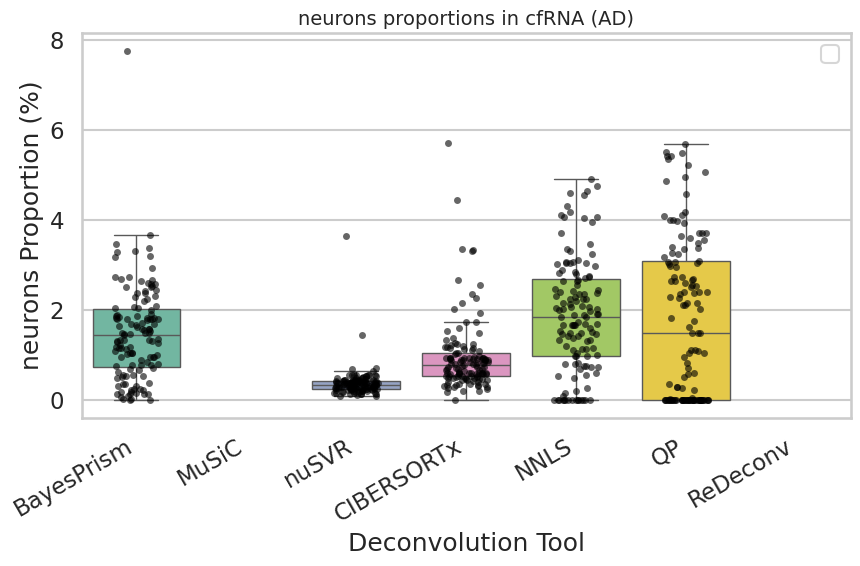

/tmp/ipykernel_323538/3713674249.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_323538/3713674249.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


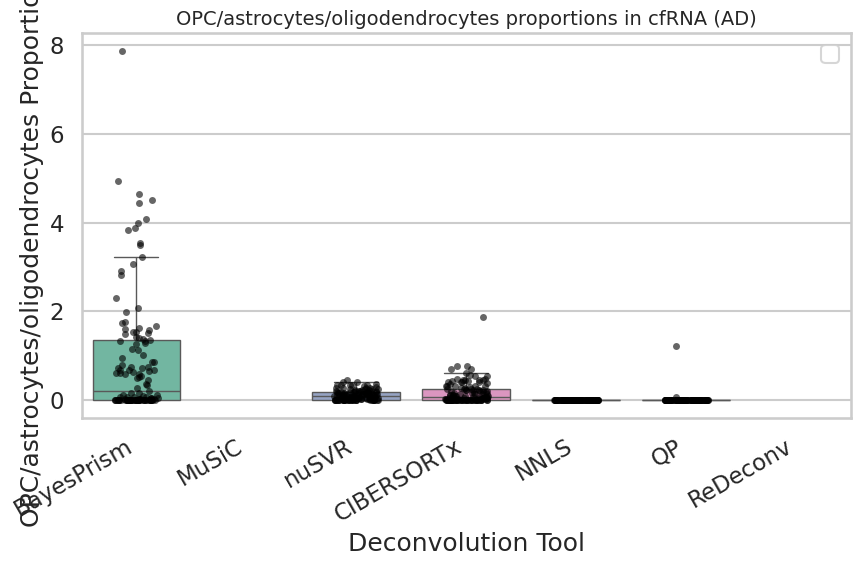

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === CONFIGURATION ===
dir_path = 'TSP-BDa_Outer_300_1500_10-Toden-AD'
merged_file = os.path.join(dir_path, 'merged_normalised_results_Toden_AD.txt')

# Load merged data
df = pd.read_csv(merged_file, sep='\t')

# Cell types of interest (adjust as needed)
celltypes_of_interest = [
    'neurons',
    'OPC/astrocytes/oligodendrocytes'
]

# Desired order of methods
method_order = ['BayesPrism', 'MuSiC', 'nuSVR', 'CIBERSORTx', 'NNLS', 'QP', 'ReDeconv']

# Set seaborn style
sns.set(style="whitegrid", context="talk")

# === PLOTTING ===
for celltype in celltypes_of_interest:
    if celltype not in df.columns:
        print(f"⚠️ Cell type '{celltype}' not found in dataset. Skipping.")
        continue

    plt.figure(figsize=(9, 6))

    # Boxplot (no outliers)
    sns.boxplot(
        data=df, x='Method', y=celltype,
        order=method_order,
        showfliers=False, palette="Set2"
    )

    # Overlay jittered points
    sns.stripplot(
        data=df, x='Method', y=celltype,
        order=method_order,
        color='black', alpha=0.6, jitter=0.2
    )

    plt.title(f'{celltype} proportions in cfRNA (AD)', fontsize=14)
    plt.xlabel('Deconvolution Tool')
    plt.ylabel(f'{celltype} Proportion (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()
